# Part 4: One-Step Generation

In [2]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

## Helpers

In [3]:
device = torch.device("cuda")

In [13]:
def model_tag(dataset, D, pred, loss):
    return f"{dataset}_D{D}_{pred}pred_{loss}loss"


def generate_samples(model, D, pred_type, device, n_gen, steps):
    denoiser = Denoiser(model, steps, D=D)
    return denoiser.generate(n_gen, pred_type, device).cpu().numpy()


def get_ground_truth(dataset, D, n_gen):
    loader = get_dataloader(name=dataset, dim=D, batch_size=n_gen)
    return next(iter(loader))[:n_gen].cpu().numpy()


def project_to_2d(samples, dataset, D):
    if D == 2:
        return samples
    loader = get_dataloader(name=dataset, dim=D, batch_size=1)
    return loader.dataset.to_2d(torch.from_numpy(samples)).numpy()


def density_coverage(gen, real, k=5):
    """Density & Coverage (Naeem et al. 2020) — manifold-aware quality metrics.

    Builds a 'manifold ball' around each real point: radius r_i = distance from
    real_i to its k-th nearest neighbour within the real set (k=5 by default).

    Density = (1 / (k * |gen|)) * sum_{j} sum_{i} 1{ ||gen_j - real_i|| < r_i }
        For every generated point, count how many real-balls contain it; average
        over generated points and divide by k. High Density = generated samples
        land in densely-populated regions of the real manifold (≈ fidelity, the
        'on-manifold' score). Can slightly exceed 1.0 when gen points cluster
        inside heavily-overlapping real-balls.

    Coverage = (1 / |real|) * sum_{i} 1{ min_j ||gen_j - real_i|| < r_i }
        Fraction of real points whose ball contains at least one generated point.
        High Coverage = the real manifold is well covered by generated samples
        (≈ diversity, catches mode collapse). Strictly in [0, 1].

    Both metrics are higher = better, and they're more robust to outliers than
    the older Precision/Recall pair (Kynkäänniemi et al. 2019)."""
    gen, real = np.asarray(gen, dtype=np.float64), np.asarray(real, dtype=np.float64)

    # Pairwise distances (real-real and gen-real). N is small (2k×2k ⇒ ~33 MB), fine.
    dr  = np.sqrt(((real[:, None, :] - real[None, :, :]) ** 2).sum(-1))
    dgr = np.sqrt(((gen[:,  None, :] - real[None, :, :]) ** 2).sum(-1))

    # Radius to k-th nearest *other* real point. Self-distance is 0 (column 0
    # after sorting), so column k gives the k-th NN.
    radii = np.sort(dr, axis=1)[:, k]                       # (N,)

    # Density: gen × real boolean of "is gen_j inside real_i's ball?"
    inside  = dgr < radii[None, :]                          # (M, N)
    density = float(inside.sum(axis=1).mean() / k)

    # Coverage: a real point is "covered" iff its nearest gen point is inside
    # its own ball. Equivalent to "at least one gen point in the ball".
    nearest_gen = dgr.min(axis=0)                           # (N,)
    coverage = float((nearest_gen < radii).mean())

    return density, coverage

def plot_grid(steps, D, pred, loss, h, n_gen, device, MODEL_DIR, FIG_DIR):
    """One figure per dataset: rows = D in {2, 8, 32}, cols = [GT, 4 pred/loss combos].
    GT cell shows ground truth in orange; remaining cells overlay generated (blue) on GT (gray).
    Per-row axis limits are fixed from the ground-truth extent so every subplot has identical
    dimensions; far-out generated points are clipped rather than rescaling the view."""
    n_rows = 3
    n_cols = len(steps) + 1

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 4 * n_rows),
        squeeze=False,
    )

    for row, dataset in enumerate(("swiss_roll", "gaussians", "circles")):
        gt = get_ground_truth(dataset, D, n_gen)
        gt2d = project_to_2d(gt, dataset, D)

        # Square, padded limits derived from GT only — shared across the row.
        x_min, x_max = gt2d[:, 0].min(), gt2d[:, 0].max()
        y_min, y_max = gt2d[:, 1].min(), gt2d[:, 1].max()
        cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
        half = 0.6 * max(x_max - x_min, y_max - y_min)
        xlim = (cx - half, cx + half)
        ylim = (cy - half, cy + half)

        ax_gt = axes[row, 0]
        ax_gt.scatter(gt2d[:, 0], gt2d[:, 1], s=3, alpha=0.6, c="orange")
        ax_gt.set_title(f"Ground Truth: {dataset}", fontsize=11)
        ax_gt.set_aspect("equal")
        ax_gt.set_xlim(xlim); ax_gt.set_ylim(ylim)
        ax_gt.set_xticks([]); ax_gt.set_yticks([])

        for offset, step in enumerate(steps):
            col = offset + 1
            ax = axes[row, col]
            tag = model_tag(dataset, D, pred, loss)

            model = JiM(hidden_dim=h, D=D).to(device)
            model.load_state_dict(torch.load(MODEL_DIR / f"{tag}.pt", map_location=device))
            model.eval()

            gen = generate_samples(model, D, pred, device, n_gen, step)
            gen2d = project_to_2d(gen, dataset, D)

            dens, cov = density_coverage(gen2d, gt2d)
            ax.scatter(gt2d[:, 0],  gt2d[:, 1],  s=3, alpha=0.25, c="gray", label="ground truth")
            ax.scatter(gen2d[:, 0], gen2d[:, 1], s=3, alpha=0.55, c="C0",   label="generated")
            ax.set_title(f"STEPS: {step}", fontsize=11)
            ax.set_aspect("equal")
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            ax.set_xticks([]); ax.set_yticks([])

            ax.text(0.02, 0.98, f"Dens {dens:.2f}\nCov  {cov:.2f}",
                    transform=ax.transAxes, ha="left", va="top", fontsize=9,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                            edgecolor="none", alpha=0.85))

    handles, labels = axes[0, 1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 1.02), fontsize=11)
    fig.suptitle(f"Sampling Efficiency", fontsize=14, y=1.05)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sampling_efficiency.png", dpi=150, bbox_inches="tight")
    plt.show()

## Q1) Sampling Efficiency

In [14]:
MODEL_DIR = Path("models/part2")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("res/part4")
FIG_DIR.mkdir(parents=True, exist_ok=True)

STEPS = (1, 2, 5, 10, 20, 50, 100, 200)

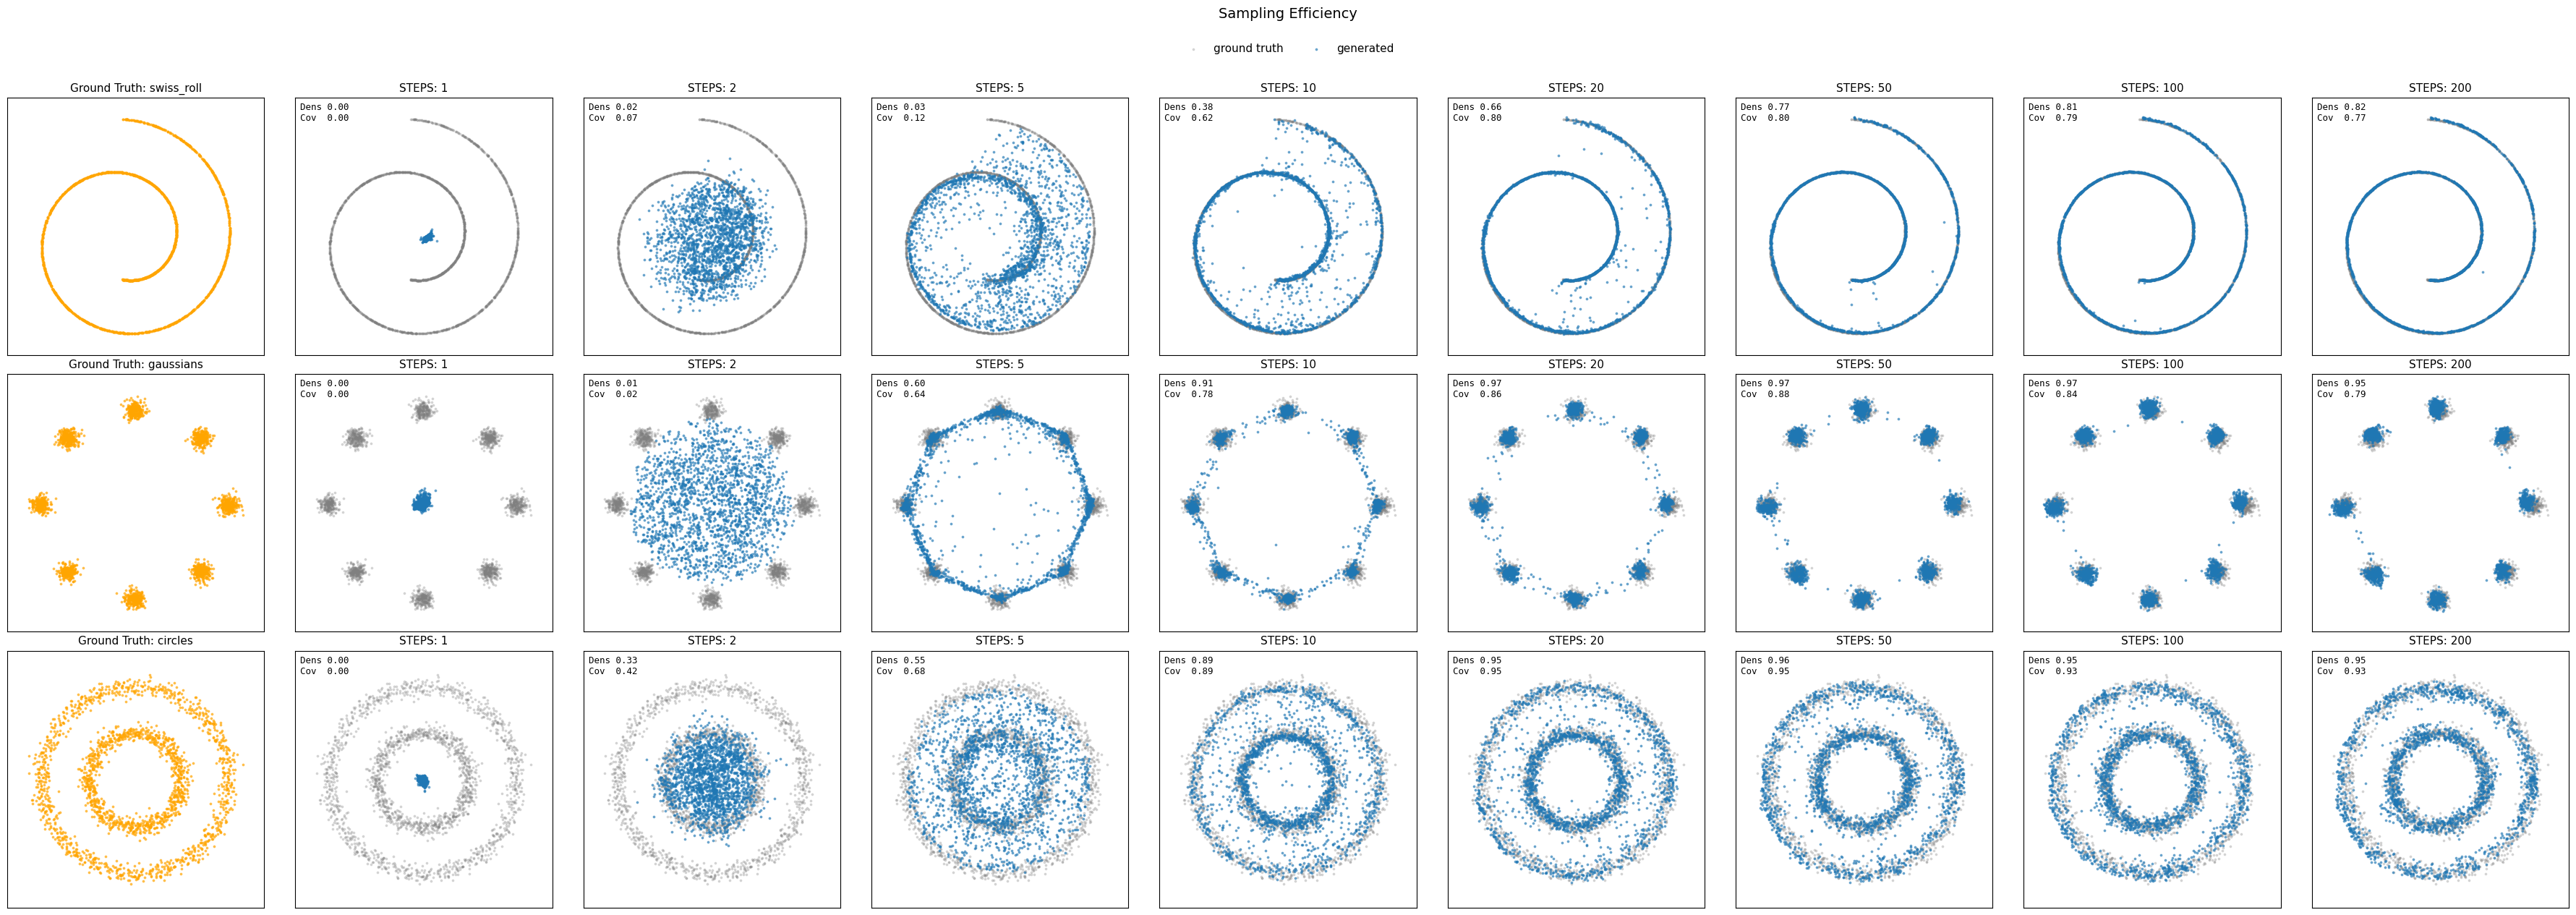

In [15]:
plot_grid(
    steps=STEPS, 
    D=2,
    pred='x', 
    loss='v', 
    h=256, 
    n_gen=2048, 
    device=device,
    MODEL_DIR=MODEL_DIR,
    FIG_DIR=FIG_DIR
)